Most people judge a team by pass completion rate. The share of passes that find a teammate. But a safe pass is not the same as dangerous one. A team can complete 95% of its passes while barely threatening the opposition, if none of these passes actually break through the defensive line. This raise the question of whether the teams that advanced further did so because they passed more accurately or because they were more willing to take the risk of breaking through defensive lines.

So my research question goes as:

**Among players who reached the knockout stage compared to those eliminated in the group stage, which better distinguishes  the two groups: penetrative passing (breaking the defense line) or passing accuracy?**

I hypothesized that penetrative passing would be the stronger differentiator between advanced and eliminated teams, while passing accuracy (a measure of ball possession rather than attack), would show little difference between the groups.

I grouped players by their team's tournament outcome: Advanced past the group stage (32 teams) versus eliminated in the group stage (16 teams), applied at individual player level since our question is more about passing behavior, not teams result. Yes, I could have use round of 16 (knockout stage) as cut off for advanced teams, but a single knockout game would not provide stable data, which three group matches gives us. This split is not perfect for team quality. Since world cup draws are seeded rather than random. Advanced team partly reflects group difficulty. We treat this as a disclosed limitation rather than a flaw that invalidates the comparison.

## Data Collection

I initially scraped player stats from an authenticated internal endpoint directly from official website (web_scrape_data.ipynb). It had coverage gaps and filling them from FBref risked cross-source name-matching errors. Before adapting a new source, we validated it against our earlier scraper.

In [126]:
# Data scraped from old scraper
import pandas as pd

dist = pd.read_csv("wc026_distribution.csv")
print(dist.shape)
print(dist.columns.tolist())

(1813, 14)
['name', 'shirt', 'team', 'passes', 'passes_completed', 'passing_accuracy_rate', 'crosses', 'crossing_accuracy_rate', 'take_ons_completed', 'linebreaks_attempted_defensive_line', 'linebreak_attempted_defensive_line_rate', 'attempted_switches_of_play', 'switches_of_play_rate', 'position']


In [127]:
# Caching so that every re run doesnt have to hit the json endpoints
# fetching teams data
import os
import json
import requests

headers = {"User-Agent": "Mozilla/5.0"}

def fetch_cached(url, file,params=None):
    if os.path.exists(file):
        with open(file, 'r') as f:
             return json.load(f)
    r = requests.get(url, params=params, headers=headers)
    data = r.json()
    with open(file, 'w') as f:
        json.dump(data, f)
    return data

teams_data = fetch_cached("https://api.fifa.com/api/v3/teamsqualified/season/285023", "teams_data.json", params={"language": "en"})

code_to_id = {t['IdCountry']: t["IdTeam"] for t in teams_data["Results"]}
print(len(code_to_id),"teams")

48 teams


Squad endpoint gives us three mappings. name_to_id connects player names and numeric ids. I need it to match players between old scraper and the new stats from API. The endpoint fetching player's data doesnt have team id. To bridge them together we need pid_to_team var. pid_to_position to map the position.

In [128]:
# Squad fetch
# Using pickle as we need to store tuples as in name_to_id, which json cannot
import pickle
import time

cache_file = 'data_cache.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        name_to_id, pid_to_position, pid_to_team = pickle.load(f)
    print(f"Loaded from cache: {len(name_to_id)} players")

else:
    name_to_id, pid_to_position, pid_to_team = {}, {}, {}

    for code, team_id in code_to_id.items():
        r = requests.get(f"https://api.fifa.com/api/v3/teams/{team_id}/squad",               params={"idCompetition": 17, "idSeason": 285023, "language": "en"},                   headers=headers)
        squad = r.json()
        for p in squad['Players']:
            pname = p["PlayerName"][0]["Description"].upper()
            pid = p["IdPlayer"]
            name_to_id[(code,pname)] = pid
            pid_to_position[int(pid)] = p["PositionLocalized"][0]["Description"]
            pid_to_team[pid] = code
        time.sleep(0.1)

    with open(cache_file, 'wb') as f:
        pickle.dump((name_to_id, pid_to_position, pid_to_team), f)
        print(f"Fetched and cached: {len(name_to_id)} players")

Loaded from cache: 1248 players


In [129]:
# Players data
players_data = fetch_cached("https://fdh-api.fifa.com/v1/stats/season/285023/players.json", "players_data.json", params={"language": "en"})
print(len(players_data))

1259


In [130]:
# fetch match data
match_data = fetch_cached("https://api.fifa.com/api/v3/calendar/matches","match_data.json",params={"idSeason": 285023, "idCompetition": 17, "count": 200})
matches = match_data['Results']
print(len(matches), "matches")
print("Duplicate match fixtures:", pd.DataFrame(matches).duplicated(subset=["IdMatch"]).sum())

104 matches
Duplicate match fixtures: 0


## Source validation

In [131]:
import random

dist_played = dist[dist['passes']>0].copy()
random.seed(42)
sample = dist_played.sample(15, random_state=42)

matched, unmatched = [], []
for _, row in sample.iterrows():
    key = (row["team"], row["name"].upper())
    if key in name_to_id:
        pid = name_to_id[key]
        api_stats = {f[0]: f[1] for f in players_data[pid]}
        if api_stats.get("TimePlayed", 0) > 0:
            matched.append((row, pid))
        else:
            unmatched.append((row["name"], "0 minutes played"))
    else:
        unmatched.append((row["name"], "no name match"))

print(f"matched: {len(matched)} / 15")
print("unmatched:", unmatched)

matched: 14 / 15
unmatched: [('Brandon Thomas Asante', 'no name match')]


Let's inspect why didnt it match.

In [132]:
row = sample[sample["name"] == "Brandon Thomas Asante"].iloc[0]
team_code = row["team"]

for k in name_to_id:
    if k[0] == team_code and "ASANTE" in k[1]:
        print(k[1])

BRANDON THOMAS-ASANTE


Its formatting error rather than data coverage error.

In [133]:
  # Append the unmatched player
matched_name = [k[1] for k in name_to_id if k[0] == team_code and "ASANTE" in k[1]][0]
pid = name_to_id[(team_code, matched_name)]
matched.append((row, pid))

In [134]:
results = []
for row, pid in matched:
    api_stats = {f[0]: f[1] for f in players_data[pid]}
    results.append({
        "name": row["name"],
        "old_passes": row["passes"], "new_passes": api_stats.get("Passes"),
        "old_completed": row["passes_completed"], "new_completed": api_stats.get("PassesCompleted"),
        "old_linebreaks": row["linebreaks_attempted_defensive_line"], "new_linebreaks": api_stats.get("LinebreaksAttemptedDefensiveLine"),
    })

comparison = pd.DataFrame(results)
print(comparison)

                     name  old_passes  new_passes  old_completed  \
0            Leo Ostigard        99.0          99           84.0   
1            Kenny Mclean        63.0          63           56.0   
2            Lionel Messi       367.0         367          288.0   
3        Deveron Fonville        66.0          66           55.0   
4               Tim Payne        87.0          87           72.0   
5            Amir Murillo       112.0         112           88.0   
6           Sondre Langas        10.0          10            9.0   
7     Amir Hadziahmetovic         3.0           3            3.0   
8        Evidence Makgopa        29.0          29           20.0   
9            Raul Jimenez        66.0          66           48.0   
10    Christian Fassnacht         5.0           5            5.0   
11         Iqraam Rayners        24.0          24           21.0   
12             Ramon Sosa         3.0           3            3.0   
13              Trezeguet        81.0          8

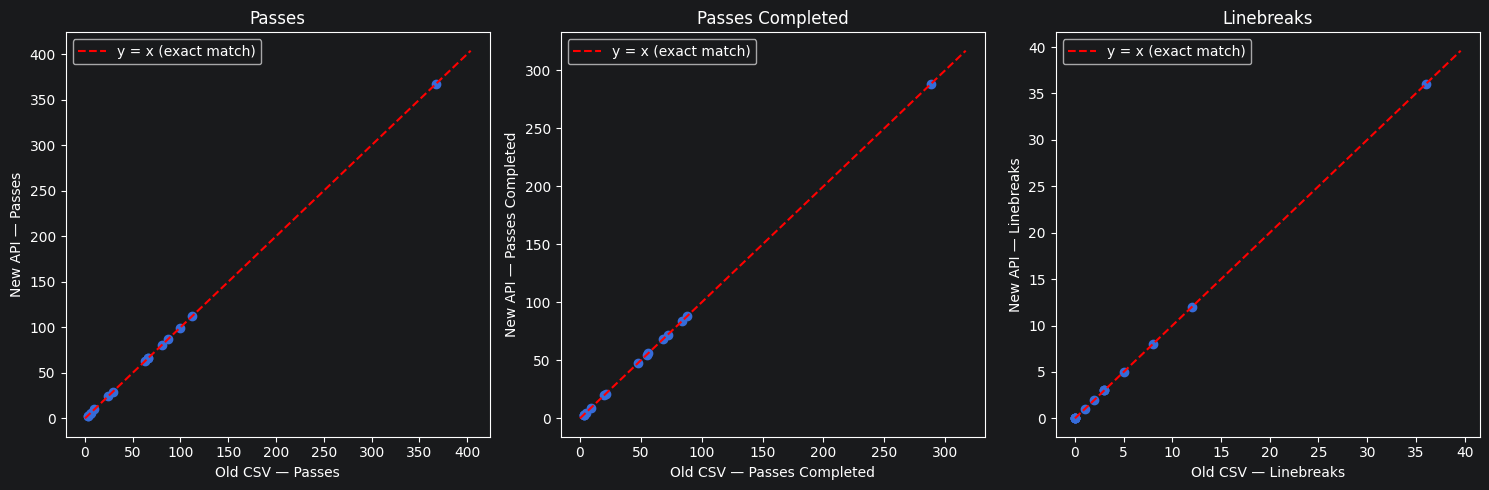

In [135]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (old_col, new_col, label) in zip(axes, [
    ("old_passes", "new_passes", "Passes"),
    ("old_completed", "new_completed", "Passes Completed"),
    ("old_linebreaks", "new_linebreaks", "Linebreaks"),
]):
    ax.scatter(comparison[old_col], comparison[new_col])
    lims = [0, max(comparison[old_col].max(), comparison[new_col].max()) * 1.1]
    ax.plot(lims, lims, 'r--', label='y = x (exact match)')
    ax.set_xlabel(f"Old CSV — {label}")
    ax.set_ylabel(f"New API — {label}")
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

All 15 sampled player's stats matched across sources. So, this API can be used as a reliable source.

### Building dataset

In [136]:
fields_needed = ['Passes', 'PassesCompleted', 'Crosses', 'LinebreaksAttemptedDefensiveLine', 'TimePlayed']
rows = []
for pid, fields in players_data.items():
    d = {f[0]: f[1] for f in fields if f[0] in fields_needed}
    d["player_id"] = pid
    rows.append(d)

players_df = pd.DataFrame(rows)
print(players_df.shape)
print(players_df.head())

(1259, 6)
   Crosses  LinebreaksAttemptedDefensiveLine  Passes  PassesCompleted  \
0        8                              13.0     165              142   
1       12                              15.0     200              161   
2       34                              17.0     201              163   
3        2                              17.0     229              207   
4       15                              13.0     474              433   

   TimePlayed player_id  
0  500.459250    430740  
1  458.662150    430605  
2  476.794633    403585  
3  535.375000    430750  
4  857.423650    430735  


In [137]:
# check duplicates
print("Duplicated player rows:", players_df['player_id'].duplicated().sum())

Duplicated player rows: 0


In [138]:
players_df['team'] = players_df["player_id"].map(pid_to_team)
print(players_df['team'].isnull().sum(), "players with no team match")
print(players_df.shape)

11 players with no team match
(1259, 7)


In [139]:
unmatched_players = players_df[players_df["team"].isna()]
print(unmatched_players)

      Crosses  LinebreaksAttemptedDefensiveLine  Passes  PassesCompleted  \
61          0                               NaN       0                0   
110         0                               NaN       0                0   
129         0                               NaN       0                0   
387         0                               NaN       0                0   
526         0                               NaN       0                0   
529         0                               NaN       0                0   
637         0                               NaN       0                0   
639         0                               NaN       0                0   
760         0                               NaN       0                0   
857         0                               NaN       0                0   
1091        0                               NaN       0                0   

      TimePlayed player_id team  
61           NaN    448291  NaN  
110          NaN   

These are the player who didn't appear in single game in 2026 world cup.We also may have players who were matched with teams but didn't played. Its better to drop the players who didn't play at all. We also dont need players with no passes as our whole question is based on passes.

In [140]:
# Separating our groups advanced/ eliminated
matches = match_data['Results']
print(matches[0])

{'IdCompetition': '17', 'IdSeason': '285023', 'IdStage': '289273', 'IdGroup': '289275', 'Weather': {'Humidity': None, 'Temperature': None, 'WindSpeed': None, 'Type': None, 'TypeLocalized': []}, 'Attendance': '80824', 'IdMatch': '400021443', 'MatchDay': None, 'StageName': [{'Locale': 'en-GB', 'Description': 'First Stage'}], 'GroupName': [{'Locale': 'en-GB', 'Description': 'Group A'}], 'CompetitionName': [{'Locale': 'en-GB', 'Description': 'FIFA World Cup™'}], 'SeasonName': [{'Locale': 'en-GB', 'Description': 'FIFA World Cup 2026™'}], 'SeasonShortName': [], 'Date': '2026-06-11T19:00:00Z', 'LocalDate': '2026-06-11T13:00:00Z', 'Home': {'Score': 2, 'Side': None, 'IdTeam': '43911', 'PictureUrl': 'https://api.fifa.com/api/v3/picture/flags-{format}-{size}/MEX', 'IdCountry': 'MEX', 'Tactics': '4-1-2-3', 'TeamType': 1, 'AgeType': 7, 'TeamName': [{'Locale': 'en-GB', 'Description': 'Mexico'}], 'Abbreviation': 'MEX', 'ShortClubName': 'Mexico', 'FootballType': 0, 'Gender': 1, 'IdAssociation': 'MEX'}

We can see, they are formatted as "First Stage".

In [141]:
advanced_ids = set() # Teams who qualified for round of 32

#  Format : 'Home': {'Score': 2, 'Side': None, 'IdTeam': '43911', 'PictureUrl': 'https://api.fifa.com/api/v3/picture/flags-{format}-{size}/MEX', 'IdCountry': 'MEX', 'Tactics': '4-1-2-3', 'TeamType': 1, 'AgeType': 7, 'TeamName': [{'Locale': 'en-GB', 'Description': 'Mexico'}],
for m in matches:
    if m["StageName"][0]["Description"] != "First Stage":
        advanced_ids.add(m["Home"]["IdTeam"])
        advanced_ids.add(m["Away"]["IdTeam"])

print(len(advanced_ids))

32


In [142]:
# Check if the country and code matches
print(len(code_to_id))
print(code_to_id['MEX'])
players_df.head()

48
43911


,Crosses,LinebreaksAttemptedDefensiveLine,Passes,PassesCompleted,TimePlayed,player_id,team
0,8,13.0,165,142,500.459250,430740,MAR
1,12,15.0,200,161,458.662150,430605,BRA
2,34,17.0,201,163,476.794633,403585,MEX
3,2,17.0,229,207,535.375000,430750,ESP
4,15,13.0,474,433,857.423650,430735,ESP


No team id , we have to get individual team code and merge it with its name.

In [143]:
id_to_advanced = {team_id: (team_id in advanced_ids) for team_id in code_to_id.values()}
players_df["team_id"] = players_df["team"].map(code_to_id)
players_df["advanced"] = players_df["team_id"].map(id_to_advanced)
players_df["position"] = players_df["player_id"].astype(int).map(pid_to_position)


print(players_df["advanced"].value_counts(dropna=False))

advanced
True     832
False    416
NaN       11
Name: count, dtype: int64


## Data Cleaning

We will be checking thresold for passes and timeplayed, so that the noise remains away from our data.

In [144]:
baseline_n = len(players_df)
print(f"Baseline (no filters): n = {baseline_n}")
print()

Baseline (no filters): n = 1259



In [145]:
for cutoff in [3, 5, 10]:
    filt = players_df[players_df['Passes'] > cutoff]
    n = len(filt)
    max_ratio = (filt['LinebreaksAttemptedDefensiveLine'] / filt['Passes'] * 100).max()
    print(f"Passes > {cutoff}: n = {n} ({n/baseline_n*100:.1f}% retained), max linebreaks_per100passes = {max_ratio:.1f}%")

Passes > 3: n = 983 (78.1% retained), max linebreaks_per100passes = 60.0%
Passes > 5: n = 953 (75.7% retained), max linebreaks_per100passes = 36.4%
Passes > 10: n = 887 (70.5% retained), max linebreaks_per100passes = 36.4%


Few passes attempted and single linebreak can produce unstable ration. To find a proper cutoff, the maximum observed ratio was checked at increasing thresholds. 3 to 5 meaningfully reduces worst-case instability, but raising further gives us no improvements. Thatswhy we will be choosing passes > 5 as the point which can reduce instability without data loss.

In [146]:
before_max_per90 = (players_df['LinebreaksAttemptedDefensiveLine'] / players_df['TimePlayed'] * 90).max()

for cutoff in [10, 20, 30]:
    filt = players_df[players_df['TimePlayed'] > cutoff]
    n = len(filt)
    max_per90 = (filt['LinebreaksAttemptedDefensiveLine'] / filt['TimePlayed'] * 90).max()
    print(f"TimePlayed > {cutoff}: n = {n} ({n/baseline_n*100:.1f}% retained), max linebreaks_per90 = {max_per90:.1f}")

TimePlayed > 10: n = 1019 (80.9% retained), max linebreaks_per90 = 29.2
TimePlayed > 20: n = 972 (77.2% retained), max linebreaks_per90 = 29.2
TimePlayed > 30: n = 930 (73.9% retained), max linebreaks_per90 = 29.2


Cutoffs in 10,20,30 minutes showed no change in max ratio, the threshold is supposed to set a baseline. The 30.8 min outlier isn't a data error. It's a real performance that looks extreme because per90 extrapolates 30.8 mins to 90. This is a limitation that comes with short, intense appearances. Rather than cherry picking data, I have decided to keep it even it results in inconvenient analysis and choosed 20 as a sport standard cutoff for per90.


In [147]:
outlier = players_df.copy()
outlier['linebreaks_per90'] = outlier['LinebreaksAttemptedDefensiveLine'] / outlier['TimePlayed'] * 90
outliers = outlier .nlargest(2, 'linebreaks_per90')[['player_id', 'team', 'Passes', 'LinebreaksAttemptedDefensiveLine', 'TimePlayed', 'linebreaks_per90']]

print(outliers)

    player_id team  Passes  LinebreaksAttemptedDefensiveLine  TimePlayed  \
595    448107  SUI     255                               6.0    0.000000   
74     494531  PAR     159                              10.0   30.777067   

     linebreaks_per90  
595               inf  
74          29.242553  


One of the outlier has 0 timeplayed with 255 passes. Lets see if there is anymore of these impossible data.

In [148]:
impossible = players_df[players_df['Passes'] < players_df['LinebreaksAttemptedDefensiveLine']]
print(len(impossible))
print(impossible[['player_id', 'team', 'Passes', 'LinebreaksAttemptedDefensiveLine', 'TimePlayed']])

2
    player_id team  Passes  LinebreaksAttemptedDefensiveLine  TimePlayed
198    356956  MAR       0                               9.0   73.401500
923    479077  UZB       0                               2.0   72.448667


These players will be removed as it looks like FIFA data bug, as its impossible to have 0 passes with non-zero linebreaks and passes with 0 timeplayed.

In [149]:
players_df = players_df[(players_df["TimePlayed"] > 20) & (players_df["Passes"]>5)].copy()
print(players_df.shape)
print(players_df["advanced"].value_counts(dropna=False))


(928, 10)
advanced
True     644
False    284
Name: count, dtype: int64


This is our dataset, no NaNs.

## Positional balance
As we know, midfielders naturally attempt more than defenders or forwards, an imbalance may lead to wrong result, independent of team quality.

In [150]:
print(pd.crosstab(players_df['position'], players_df['advanced'], normalize='columns') * 100)

advanced        False      True 
position                        
Defender    37.676056  33.850932
Forward     24.647887  26.863354
Goalkeeper   6.338028   5.900621
Midfielder  31.338028  33.385093


Midfielder's make up 31% of eliminated vs 33.4% of advanced-team with all other positions similarly close. Therefore, there is no meaningfull differences and unlikely to be effecting the results.

## Feature Engineering
I used linebreaks attempted at defense line specifically because it counts the passes that breaks the last line of defense which signals dangerous linebreaks. The raw overall linebreaks was not used because it sums all linebreaks at midfield and attacking lines too which may not be penetrative passing. Assists was also considered but rejected as simple pass before a goal, tap-ins are not related to penetrative passing in any aspect. This is our question, does the team players try to break the last defense line more or keeps on build up or possession? The another metric measures the passing accuracy. We want the metric that precisely captures a pass creating genuine threat rather than generic progression.

Crosses per90 gives us a second measure of penetration through wide channel. Wide play rather than central line-breaks. A team that crosses more is taking a risk in a different way than one that breaks line centrally, so this metric broadens penetration rather than relying on one channel.

I normalised LineBreakAttempted by two ways: per 90-minutes and per 100-passes. Per-90 controls for eliminated teasm playing fewer matches and having less total time played compared to advanced ones. Per-100 passes  isolates passing style independent of the time. Comparing both lets us tell whether any group difference reflects genuinely more direct play or just more oppurtunity to rack up raw output.

In [151]:
# Check Nulls
players_df.isna().sum()

Crosses                             0
LinebreaksAttemptedDefensiveLine    0
Passes                              0
PassesCompleted                     0
TimePlayed                          0
player_id                           0
team                                0
team_id                             0
advanced                            0
position                            0
dtype: int64

In [152]:
players_df['linebreaks_per90'] = players_df['LinebreaksAttemptedDefensiveLine'] / players_df['TimePlayed'] * 90
players_df['linebreaks_per100passes'] = players_df['LinebreaksAttemptedDefensiveLine'] / players_df['Passes'] * 100
players_df['crosses_per90'] = players_df['Crosses'] / players_df['TimePlayed'] * 90
players_df['passing_accuracy_rate'] = players_df['PassesCompleted'] / players_df['Passes'] * 100

In [153]:
print(players_df.head())

   Crosses  LinebreaksAttemptedDefensiveLine  Passes  PassesCompleted  \
0        8                              13.0     165              142   
1       12                              15.0     200              161   
2       34                              17.0     201              163   
3        2                              17.0     229              207   
4       15                              13.0     474              433   

   TimePlayed player_id team team_id advanced    position  linebreaks_per90  \
0  500.459250    430740  MAR   43872     True     Forward          2.337853   
1  458.662150    430605  BRA   43924     True  Midfielder          2.943343   
2  476.794633    403585  MEX   43911     True     Forward          3.208929   
3  535.375000    430750  ESP   43969     True     Forward          2.857810   
4  857.423650    430735  ESP   43969     True    Defender          1.364553   

   linebreaks_per100passes  crosses_per90  passing_accuracy_rate  
0                 7

In [154]:
players_df.to_csv('passing.csv', index=False)

## Data Sampling
I used stratified random sampling (subgrouping as representation from each group matters) technique to draw an equal random sample (n=120) from each group (advanced,eliminated) to ensure balanced representation for a fair between-group comparison, with a fixed random seed.

In [155]:
SAMPLE_N = 120
RANDOM_SEED = 42

# Sort by player_id first, so that random seed produces identical sample every run
players_df = players_df.sort_values('player_id').reset_index(drop=True)

sample_adv = players_df[players_df['advanced'] == True].sample(n=SAMPLE_N, random_state=RANDOM_SEED)
sample_elim = players_df[players_df['advanced'] == False].sample(n=SAMPLE_N, random_state=RANDOM_SEED)

sample_df = pd.concat([sample_adv, sample_elim], ignore_index=True)

print(sample_df['advanced'].value_counts())
print(f"Total sample size: {len(sample_df)}")

advanced
True     120
False    120
Name: count, dtype: int64
Total sample size: 240


## Descriptive stats
Let's inspect what we got on each metrics.

In [156]:
print(sample_df.groupby('advanced')['linebreaks_per100passes'].describe().round(2))

          count  mean   std  min   25%   50%   75%    max
advanced                                                 
False     120.0  5.27  5.18  0.0  1.22  4.64  7.14  31.58
True      120.0  5.45  5.41  0.0  1.20  4.01  8.48  25.00


This metric measures passing style independent of playing time.
Both groups show mean < median  which indicates a right-skewed distribution. But here mean and median disagree, the mean is marginally higher for advanced team and median is higher for eliminated. This gap suggests the mean is being driven by small number of outliers players rather than a genuine difference. The median is the more representative summary and points towards eliminated teams.

In [157]:
print(sample_df.groupby('advanced')['linebreaks_per90'].describe().round(2))

          count  mean   std  min   25%   50%   75%    max
advanced                                                 
False     120.0  1.57  1.69  0.0  0.44  1.35  2.16  11.83
True      120.0  1.74  1.55  0.0  0.39  1.35  2.83   8.53


This metric measures linebreaks directly dependent with playing time.Both groups are right skewed (mean exceeds median on both groups).Here advanced teams have higher mean and  identical on median which supports advanced teams having subset of high-output players.


In [158]:
print(sample_df.groupby('advanced')['crosses_per90'].describe().round(2))

          count  mean   std  min  25%   50%   75%   max
advanced                                               
False     120.0  1.21  1.67  0.0  0.0  0.41  1.77  7.06
True      120.0  1.36  1.79  0.0  0.0  0.70  2.02  8.51


This metric measures wide penetration. Both groups are strongly right skewed (SD exceeds mean in both) with a long tail. Advanced team lead on both mean and median, a consistent signal. Here both central tendency measures agree that advanced team players cross more.

In [159]:
print(sample_df.groupby('advanced')['passing_accuracy_rate'].describe().round(2))

          count   mean    std    min    25%    50%    75%    max
advanced                                                        
False     120.0  80.35  10.53  50.00  74.87  81.82  88.57  100.0
True      120.0  83.82   8.92  46.15  78.46  85.65  89.87  100.0


This metric measures passing/safety success. SD is much smaller than the mean in both groups, mean sits slightly below median in both (80.35 vs 81.82 ; 83.82 vs 85.65). Its a mild left skew, maybe due to low-accuracy outliers compared with 100%. Advanced players show higher accuracy on both mean and median with both agreeing on same direction and a gap that is large relative the metrics spread.

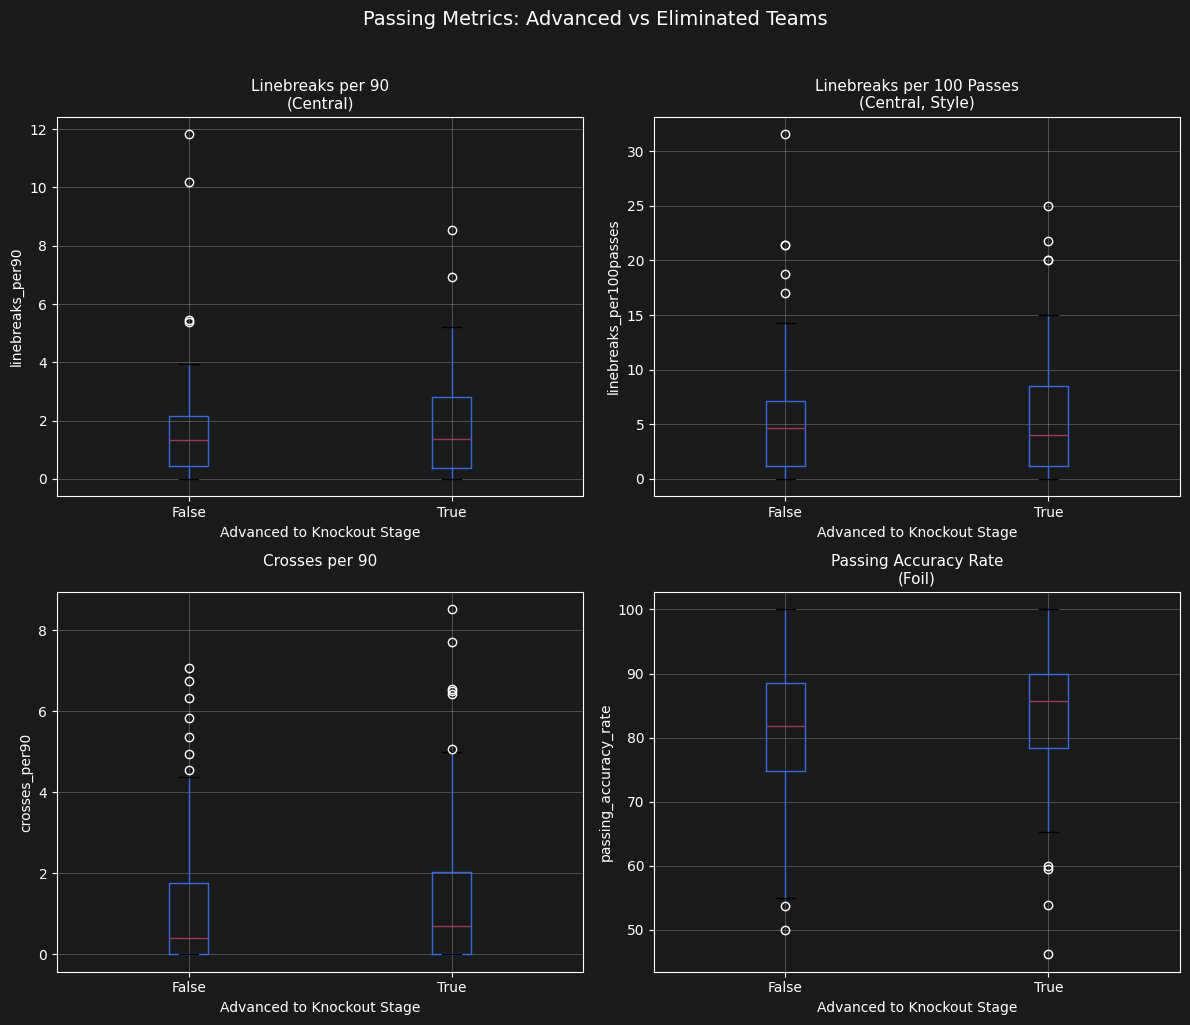

In [160]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = [
    ('linebreaks_per90', 'Linebreaks per 90\n(Central)'),
    ('linebreaks_per100passes', 'Linebreaks per 100 Passes\n(Central, Style)'),
    ('crosses_per90', 'Crosses per 90\n'),
    ('passing_accuracy_rate', 'Passing Accuracy Rate\n(Foil)')
]

for ax, (col, title) in zip(axes.flat, metrics):
    sample_df.boxplot(column=col, by='advanced', ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Advanced to Knockout Stage')
    ax.set_ylabel(col)

plt.suptitle('')
fig.suptitle('Passing Metrics: Advanced vs Eliminated Teams', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('all_metrics_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Outliers remain visible even after the data was thresolded (>5 passes, >20 mins). These remaining outliers were investigated while filtering. Some are low volume players where a small denominator make the ratio unstable and some are genuine high-volume performances distorted by extrapolating a short cameo to a full 90 minutes. In both cases, the values are real, correctly recorded data and are retained and disclosed as limitation. This right-skew is why both mean and median are reported throughout.

## Confidence Interval & t test
The descriptive stats shows apparent differences between groups, with only a sample. Thoose differences could be real or just random sampling variation. The 95% confidence interval estimates the plausible range for the population difference (advanced-eliminated). The two sample test gives us a p-value, which tells us the probability of seeing a gap this large if the two groups were truly identical. Moreover,it tell us how confident we can be that a real gap that the sample showed in descriptive stats. I will also be reporting cohen's d, that reports effect size : how large the gap is, not just whether its statistically real.

I am using two-tailed test here because my research question asks whether the group differs, not which direction. If we use one-tailed and the hypothesis gets reversed, we wouldn't even know it.

### Independence check
We expected, its common sense that players from the same team would not be fully independent observations. A team share same tactic's, gameplan and style of play. Therefore, the variance within a team would be smaller than the random players from each group.

In [161]:
for col in ['linebreaks_per90', 'linebreaks_per100passes', 'crosses_per90', 'passing_accuracy_rate']:
    overall_std = players_df[col].std()
    within_team_std = players_df.groupby('team')[col].std().mean()
    print(f"{col}: overall std={overall_std:.2f}, within-team std={within_team_std:.2f}")

linebreaks_per90: overall std=1.71, within-team std=1.49
linebreaks_per100passes: overall std=5.37, within-team std=5.10
crosses_per90: overall std=1.90, within-team std=1.76
passing_accuracy_rate: overall std=10.14, within-team std=9.26


This confirms what we expected. We had a choice between team level and player level where team level would be independent obseravtions. We choosed player level as it gave us 5x increase in sample size,giving us more statistical power compared to independence violation.

## Normality
Three metrics are right skewed, and one of them is mildly left skewed. None of them are normally distributed. CLT still justifies the t-test here, because n=120 per group is large enough for the sampling mean to converge to normal regardless of skewness in our data. This does rely on independence on some degree. Thats the exact tradeoff, to solve this clustering/standard-error issue, we have to get independent observations which well get us less sample i.e n = 48, with less statistical power.

## Equal variance
We check with Levene's test for transparency,but use Welch's test regardless of results. As it's the safer default and doesn't require equal variances to be valid.

In [162]:
from scipy import stats

for col in ['linebreaks_per90', 'linebreaks_per100passes', 'crosses_per90', 'passing_accuracy_rate']:
    adv = sample_df[sample_df['advanced'] == True][col]
    elim = sample_df[sample_df['advanced'] == False][col]
    stat, p = stats.levene(adv, elim)
    print(f"{col}: stat={stat:.2f}, Levene's p={p:.2f}")

linebreaks_per90: stat=1.34, Levene's p=0.25
linebreaks_per100passes: stat=0.78, Levene's p=0.38
crosses_per90: stat=0.25, Levene's p=0.62
passing_accuracy_rate: stat=3.94, Levene's p=0.05


Three metrics show no differences since levene's p > 0.05 which says variance are statistically invaried and they hold equal variance assumption. But passing sits exactly at the cutoff which says equal variance assumption failed here. And student t-test would still give us a number but a shaky one as we know this assumes that both group have equal variances. Here, welch's test not only becomes a default test but a correct one.

In [163]:
def ci_and_ttest(df, metric_col, group_col='advanced', confidence=0.95):
    '''
    Two-sample two-tailed test, CI for the mean difference
    '''
    adv = df[df[group_col]==True][metric_col]
    elim = df[df[group_col]==False][metric_col]

    result = stats.ttest_ind(adv, elim, equal_var=False) # Welch's test
    ci = result.confidence_interval(confidence_level=confidence)
    mean_diff = adv.mean() - elim.mean()

    # Cohen's d
    pooled_std = ((adv.std()**2 +elim.std()**2)/2)**0.5
    cohens_d = mean_diff / pooled_std

    print(f"---{metric_col}---")
    print(f"Advanced: n= {len(adv)}, mean={adv.mean():.3f}")
    print(f"Eliminated: n= {len(elim)}, mean={elim.mean():.3f}")
    print(f"Mean difference(Advanced - Eliminated): {mean_diff:.3f}")
    print(f"t-statistic:{result.statistic:.3f}")
    print(f"p-value(two tailed):{result.pvalue:.3f}")
    print(f"{int(confidence*100)}% confidence interval: {ci.low:.3f}, {ci.high:.3f}")
    print(f"Cohen's d:{cohens_d:.3f}")
    print()
    return result, ci, cohens_d

---linebreaks_per90---
Advanced: n= 120, mean=1.741
Eliminated: n= 120, mean=1.571
Mean difference(Advanced - Eliminated): 0.170
t-statistic:0.812
p-value(two tailed):0.418
95% confidence interval: -0.242, 0.581
Cohen's d:0.105

---linebreaks_per100passes---
Advanced: n= 120, mean=5.450
Eliminated: n= 120, mean=5.266
Mean difference(Advanced - Eliminated): 0.183
t-statistic:0.268
p-value(two tailed):0.789
95% confidence interval: -1.163, 1.530
Cohen's d:0.035

---crosses_per90---
Advanced: n= 120, mean=1.362
Eliminated: n= 120, mean=1.208
Mean difference(Advanced - Eliminated): 0.154
t-statistic:0.689
p-value(two tailed):0.491
95% confidence interval: -0.287, 0.596
Cohen's d:0.089

---passing_accuracy_rate---
Advanced: n= 120, mean=83.816
Eliminated: n= 120, mean=80.355
Mean difference(Advanced - Eliminated): 3.461
t-statistic:2.747
p-value(two tailed):0.006
95% confidence interval: 0.978, 5.944
Cohen's d:0.355



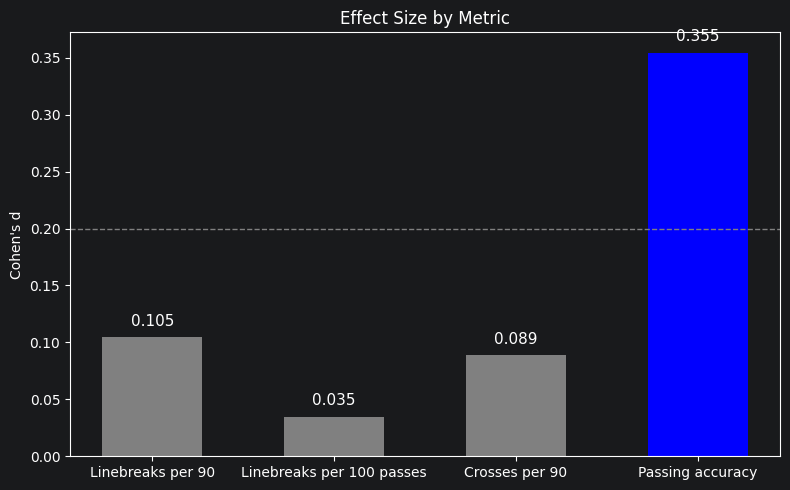

In [174]:
metrics = ['linebreaks_per90', 'linebreaks_per100passes', 'crosses_per90', 'passing_accuracy_rate']
labels = ['Linebreaks per 90', 'Linebreaks per 100 passes', 'Crosses per 90', 'Passing accuracy']

cohens_ds = []
for metric in metrics:
    result, ci, cohens_d = ci_and_ttest(sample_df, metric)
    cohens_ds.append(cohens_d)

colors = ['gray' if v < 0.2 else 'blue' for v in cohens_ds]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, cohens_ds, color=colors, width=0.55)

for bar, val in zip(bars, cohens_ds):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha='center', fontsize=11)

ax.axhline(0.2, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel("Cohen's d")
ax.set_title("Effect Size by Metric")
plt.tight_layout()
plt.savefig('cohens_d_chart.png', dpi=200, bbox_inches='tight')
plt.show()

## Findings
I had hypothesized that penetrative passing would separate advanced and eliminated teams and passing accuracy would not be much of a signal to separate. The statistical results reversed it. None of the penetration signals reached significance: linebreaks per 90 (p= 0.418), linebreaks per 100 passes (p =0.789), and crosses per 90 (p=0.491), all had confidence intervals near to zero or specifically negative. However passing accuracy was the only metric that separated the groups (t = 2.7, p =0.006,95% CI [0.978, 5.9]. And the effect sizes confirm the pattern. All three penetration measures have negligible cohen's d, while passing shows a small-medium effect which says it has statistical and practical significance.

Although the independence violation means our exact p-value shouldn't be taken at face value. But the agreement between statistical significance (p = 0.006) and effect size (Cohen's d =0.355) gives us confidence in the result itself. Two independent measures pointing the same direction is stronger evidence than either alone. That concludes, we can take this p value's result with reasonable confidence, despite the imprecision from independence.

On descriptive stats, advanced teams clearly led on every metric that included penetration measures,but only passing accuracy gap survived the test. This is why CI and t-test matters, otherwise the gap seen there would have been mistake for real gaps. This test suggested us that technical execution differntiated the advanced teams rather than tactical approach. Advanced and eliminated teams attempted penetrative passing at statistically unvaried rate. The tactical approach of breaking lines and creating chances didn't separate teams, the clean execution of retaining the ball overally did.

## Limitations
1. Player's from the same team aren't fully independent observations, which may violate independence assumptions(addressed in Independence Check, CI and t-test)
2. Per 90 metrics extrapolates short intense cameos, which can distort ratios for players with limited playing time. This is explicitly mentioned in data cleaning section. We kept a threshold and any players above the thresold were counted in as genuine performers rather than data errors, but the risk of extrapolation remains.
3. Some low-volume players still produce unstable ratios even after passes>5 and timeplayed >20 thresholds. Thresholds reduce but can't eliminate instability.
4. Our group division is imperfect proxy for team quality, this is addressed in grouping methodology section.